In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
from google.colab import files
uploaded=files.upload()

Saving insurance.csv to insurance (1).csv


In [74]:
df=pd.read_csv("insurance.csv")

In [75]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [76]:
df.shape

(1338, 7)

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [78]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [79]:
df.duplicated().sum()

np.int64(1)

In [80]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [81]:
df.drop_duplicates(inplace=True)

In [82]:
df.duplicated().sum()

np.int64(0)

In [83]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [84]:
df.describe(include="object")

,sex,smoker,region
count,1337,1337,1337
unique,2,2,4
top,male,no,southeast
freq,675,1063,364


In [85]:
for column in ["sex", "smoker", "region"]:
    print(column, ":", df[column].unique())

sex : ['female' 'male']
smoker : ['yes' 'no']
region : ['southwest' 'southeast' 'northwest' 'northeast']


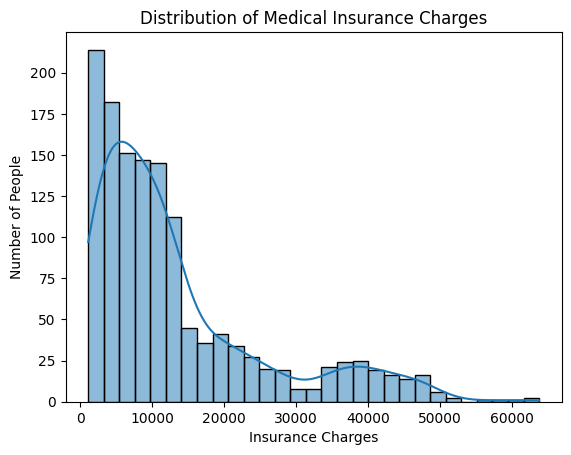

In [86]:
sns.histplot(data=df, x="charges", kde=True)
plt.title("Distribution of Medical Insurance Charges")
plt.xlabel("Insurance Charges")
plt.ylabel("Number of People")
plt.show()

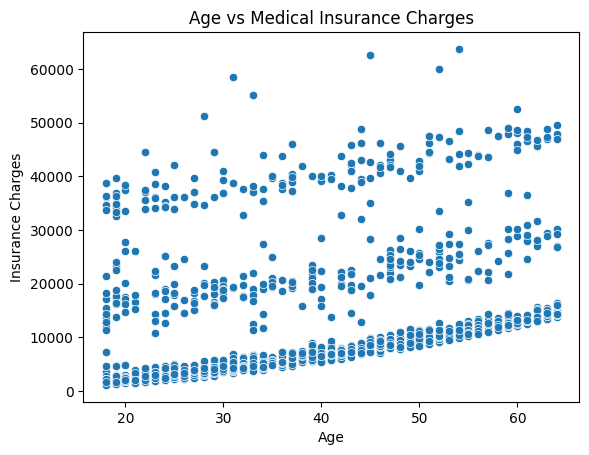

In [87]:
sns.scatterplot(data=df, x="age", y="charges")
plt.title("Age vs Medical Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Insurance Charges")
plt.show()

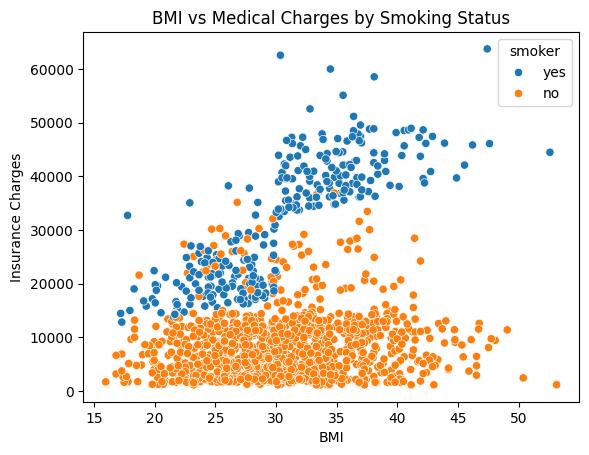

In [88]:
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker")
plt.title("BMI vs Medical Charges by Smoking Status")
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")
plt.show()

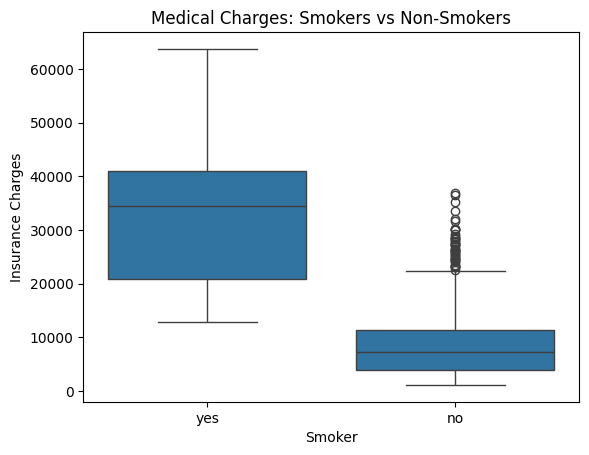

In [89]:
sns.boxplot(data=df, x="smoker", y="charges")
plt.title("Medical Charges: Smokers vs Non-Smokers")
plt.xlabel("Smoker")
plt.ylabel("Insurance Charges")
plt.show()

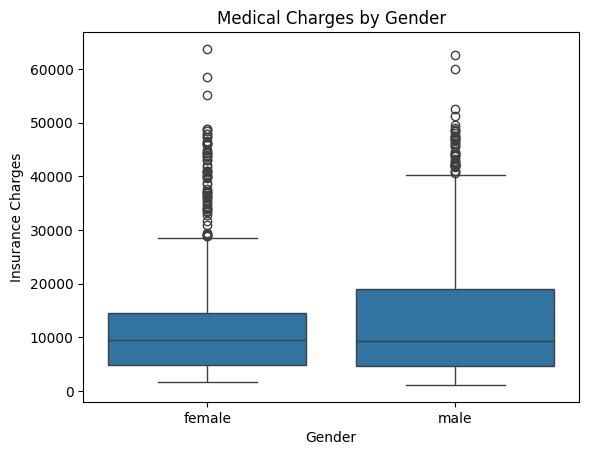

In [90]:
sns.boxplot(data=df, x="sex", y="charges")
plt.title("Medical Charges by Gender")
plt.xlabel("Gender")
plt.ylabel("Insurance Charges")
plt.show()

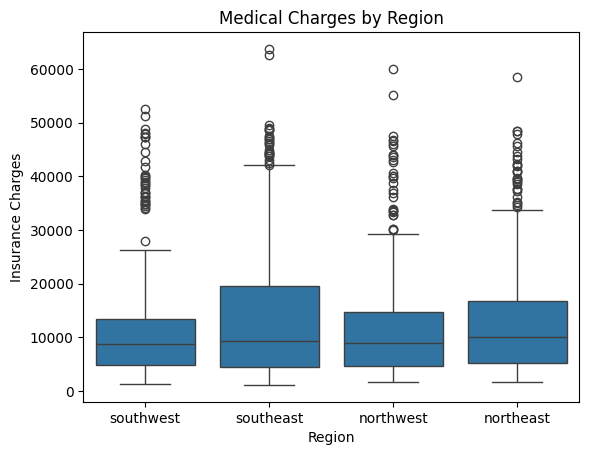

In [91]:
sns.boxplot(data=df, x="region", y="charges")
plt.title("Medical Charges by Region")
plt.xlabel("Region")
plt.ylabel("Insurance Charges")
plt.show()

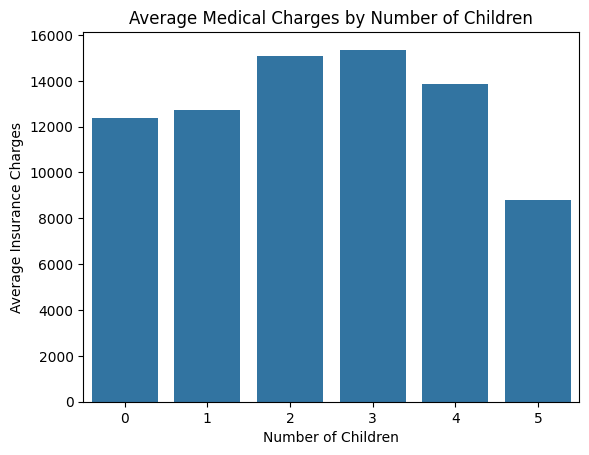

In [92]:
sns.barplot(data=df, x="children", y="charges", errorbar=None)
plt.title("Average Medical Charges by Number of Children")
plt.xlabel("Number of Children")
plt.ylabel("Average Insurance Charges")
plt.show()

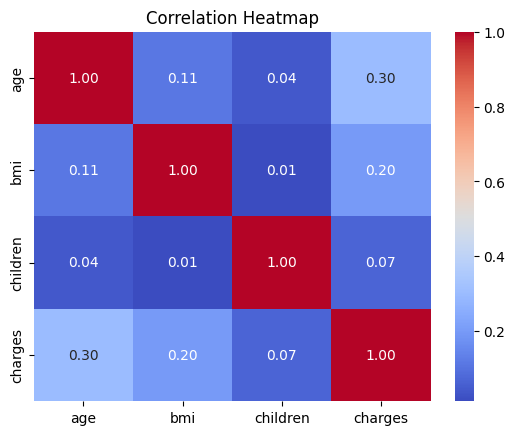

In [93]:
numerical_columns = ["age", "bmi", "children", "charges"]

correlation = df[numerical_columns].corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [94]:
x=df.drop("charges",axis=1)
y=df["charges"]

In [95]:
from sklearn.model_selection import train_test_split
x_train, x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [96]:
print("Training data: ",x_train.shape)
print("Testing data: ",x_test.shape)

Training data:  (1069, 6)
Testing data:  (268, 6)


In [97]:
numerical_columns=['age','bmi','charges','children']
categorical_columns=['sex','smoker','region']

In [98]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        )
    ],
    remainder="passthrough"
)

In [99]:
x_train_processed=preprocessor.fit_transform(x_train)
x_test_processed=preprocessor.transform(x_test)

In [100]:
print("Training preprocessed data: ",x_train_processed.shape)
print("Testing preprocessed data: ",x_test_processed.shape)

Training preprocessed data:  (1069, 11)
Testing preprocessed data:  (268, 11)


In [101]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train_processed,y_train)

LinearRegression()

In [102]:
y_pred = model.predict(x_test_processed)

In [103]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 4177.045561036321


In [104]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 5956.342894363582


In [105]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.8069287081198016


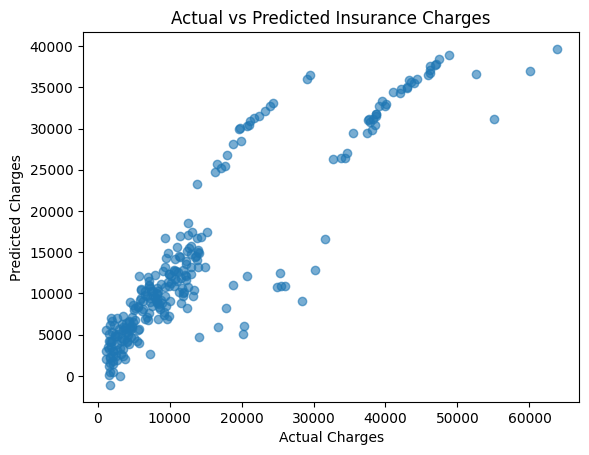

In [106]:
plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")

plt.show()

In [107]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(x_train_processed, y_train)

RandomForestRegressor(random_state=42)

In [108]:
rf_y_pred = rf_model.predict(x_test_processed)

In [109]:
rf_mae = mean_absolute_error(y_test, rf_y_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_y_pred))
rf_r2 = r2_score(y_test, rf_y_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²:", rf_r2)

Random Forest MAE: 2559.4759595925366
Random Forest RMSE: 4651.659282053165
Random Forest R²: 0.8822464216937528


In [110]:
model_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, rf_mae],
    "RMSE": [rmse, rf_rmse],
    "R² Score": [r2, rf_r2]
})

model_comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,4177.045561,5956.342894,0.806929
1,Random Forest,2559.475960,4651.659282,0.882246


In [111]:
rf_train_score = rf_model.score(x_train_processed, y_train)
rf_test_score = rf_model.score(x_test_processed, y_test)

print("Training R²:", rf_train_score)
print("Testing R²:", rf_test_score)

Training R²: 0.9742990092580271
Testing R²: 0.8822464216937528


In [112]:
tuned_rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

tuned_rf_model.fit(x_train_processed, y_train)

RandomForestRegressor(max_depth=8, min_samples_leaf=2, min_samples_split=5,
                      random_state=42)

In [113]:
tuned_rf_train_score = tuned_rf_model.score(x_train_processed, y_train)
tuned_rf_test_score = tuned_rf_model.score(x_test_processed, y_test)

print("Tuned Training R²:", tuned_rf_train_score)
print("Tuned Testing R²:", tuned_rf_test_score)

Tuned Training R²: 0.9206454592417754
Tuned Testing R²: 0.8954685283926238


In [114]:
tuned_rf_pred = tuned_rf_model.predict(x_test_processed)

tuned_rf_mae = mean_absolute_error(y_test, tuned_rf_pred)
tuned_rf_rmse = np.sqrt(mean_squared_error(y_test, tuned_rf_pred))

print("Tuned Random Forest MAE:", tuned_rf_mae)
print("Tuned Random Forest RMSE:", tuned_rf_rmse)

Tuned Random Forest MAE: 2438.6769403466988
Tuned Random Forest RMSE: 4382.726524778313


In [115]:
final_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "MAE": [
        mae,
        rf_mae,
        tuned_rf_mae
    ],
    "RMSE": [
        rmse,
        rf_rmse,
        tuned_rf_rmse
    ],
    "R² Score": [
        r2,
        rf_r2,
        tuned_rf_test_score
    ]
})

final_comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,4177.045561,5956.342894,0.806929
1,Random Forest,2559.475960,4651.659282,0.882246
2,Tuned Random Forest,2438.676940,4382.726525,0.895469


In [116]:
import joblib
joblib.dump(preprocessor, "preprocessor.pkl")
joblib.dump(tuned_rf_model, "insurance_model.pkl")

['insurance_model.pkl']

In [117]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib


# --------------------------------------------------
# Page configuration
# --------------------------------------------------
st.set_page_config(
    page_title="Medical Insurance Cost Predictor",
    page_icon="🏥",
    layout="centered"
)


# --------------------------------------------------
# Load saved model and preprocessor
# --------------------------------------------------
@st.cache_resource
def load_files():
    model = joblib.load("insurance_model.pkl")
    preprocessor = joblib.load("preprocessor.pkl")
    return model, preprocessor


model, preprocessor = load_files()


# --------------------------------------------------
# Application heading
# --------------------------------------------------
st.title("🏥 Medical Insurance Cost Predictor")

st.write(
    "Enter the person's details to estimate their medical insurance cost."
)


# --------------------------------------------------
# User inputs
# --------------------------------------------------
age = st.number_input(
    "Age",
    min_value=18,
    max_value=100,
    value=30,
    step=1
)

sex = st.selectbox(
    "Sex",
    options=["female", "male"]
)

bmi = st.number_input(
    "BMI",
    min_value=10.0,
    max_value=60.0,
    value=25.0,
    step=0.1
)

children = st.number_input(
    "Number of Children",
    min_value=0,
    max_value=10,
    value=0,
    step=1
)

smoker = st.selectbox(
    "Smoker",
    options=["no", "yes"]
)

region = st.selectbox(
    "Region",
    options=[
        "northeast",
        "northwest",
        "southeast",
        "southwest"
    ]
)


# --------------------------------------------------
# Prediction
# --------------------------------------------------
if st.button("Predict Insurance Cost", use_container_width=True):

    input_data = pd.DataFrame({
        "age": [age],
        "sex": [sex],
        "bmi": [bmi],
        "children": [children],
        "smoker": [smoker],
        "region": [region]
    })

    processed_input = preprocessor.transform(input_data)

    prediction = model.predict(processed_input)[0]

    st.success(
        f"Estimated Medical Insurance Cost: ${prediction:,.2f}"
    )

    st.caption(
        "This prediction is generated by a machine-learning model "
        "and should not be treated as an actual insurance quotation."
    )

Overwriting app.py


In [118]:
import pandas
import numpy
import sklearn
import joblib
print(pandas.__version__)
print(numpy.__version__)
print(sklearn.__version__)
print(joblib.__version__)

2.2.2
2.0.2
1.6.1
1.5.3


In [119]:
%%writefile requirements.txt
pandas==2.2.2
numpy===2.0.2
scikit-learn==1.6.1
joblib==1.5.3

Overwriting requirements.txt


In [120]:
%%writefile .gitignore

__pycache__/
*.py[cod]
.venv/
venv/
env/
.streamlit/secrets.toml
.DS_Store
insurance.csv

Overwriting .gitignore


In [121]:
!zip medical-insurance-predictor.zip app.py insurance_model.pkl preprocessor.pkl requirements.txt .gitignore

updating: app.py (deflated 66%)
updating: insurance_model.pkl (deflated 68%)
updating: preprocessor.pkl (deflated 60%)
updating: requirements.txt (deflated 10%)
updating: .gitignore (deflated 12%)
